In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv(r"train.csv")
data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
test_data = pd.read_csv(r"test.csv")
test_data.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [5]:
data.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

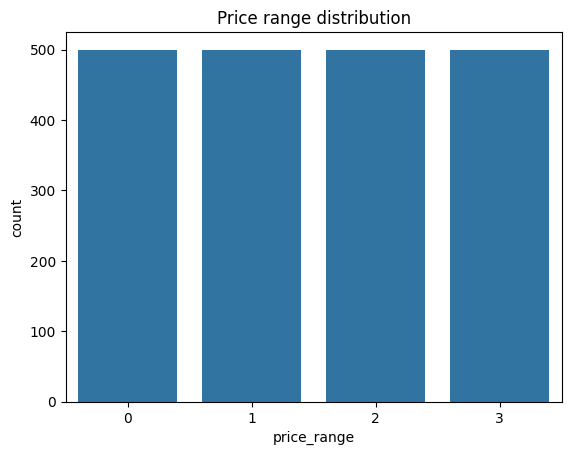

In [8]:
sns.countplot(x='price_range', data=data)
plt.title("Price range distribution")
plt.show()

In [9]:
len(data)

2000

In [10]:
len(test_data)

1000

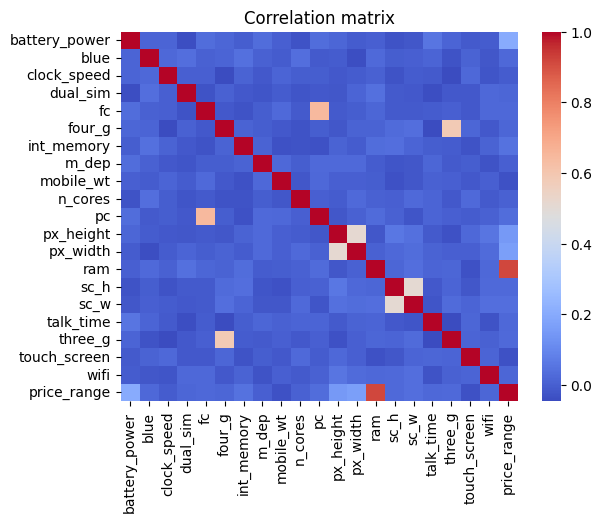

In [13]:
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation matrix",)
plt.show()

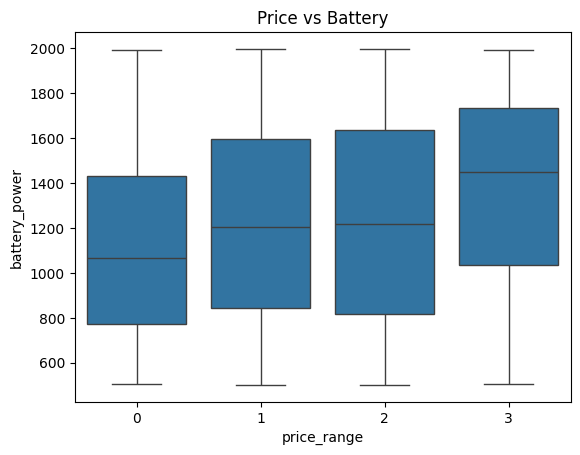

In [14]:
sns.boxplot(x='price_range', y='battery_power', data=data)
plt.title("Price vs Battery")
plt.show()

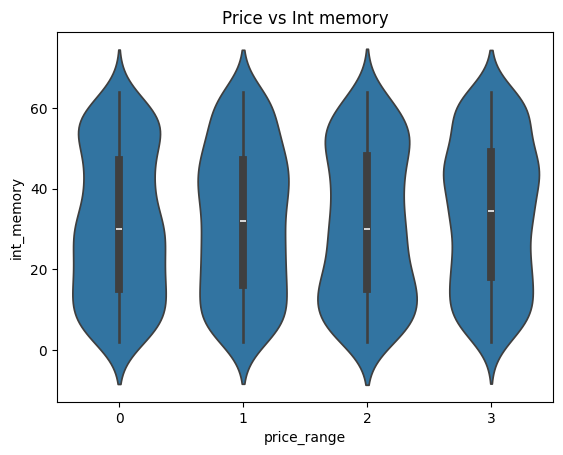

In [16]:
sns.violinplot(x='price_range', y='int_memory', data=data)
plt.title("Price vs Int memory")
plt.show()

<Axes: xlabel='battery_power', ylabel='ram'>

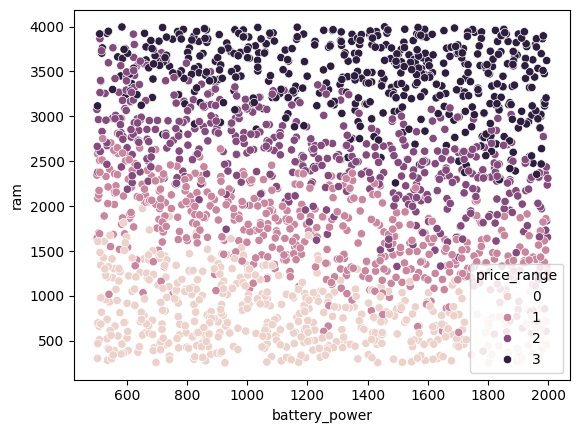

In [17]:
sns.scatterplot(x='battery_power', y='ram', data=data, hue='price_range')

In [18]:
data['resulation'] = data.px_height * data.px_width

In [19]:
test_data['resulation'] = test_data.px_height * test_data.px_width

In [20]:
data.head(2)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,resulation
0,842,0,2.2,0,1,0,7,0.6,188,2,...,756,2549,9,7,19,0,0,1,1,15120
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,1988,2631,17,3,7,1,1,0,2,1799140


In [21]:
test_data.head(2)

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,resulation
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,226,1412,3476,12,7,2,0,1,0,319112
1,2,841,1,0.5,1,4,1,61,0.8,191,...,746,857,3895,6,0,7,1,0,0,639322


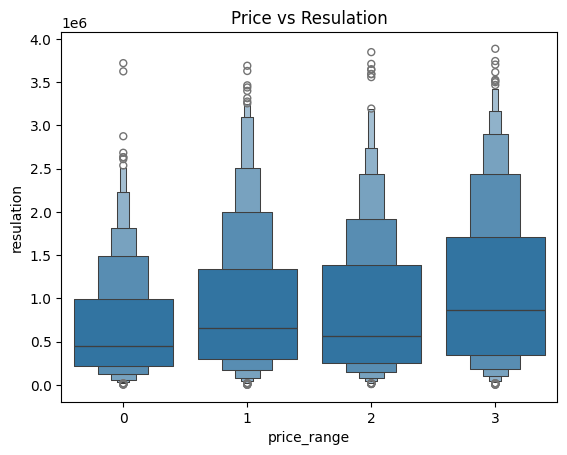

In [23]:
sns.boxenplot(x='price_range', y='resulation', data=data)
plt.title("Price vs Resulation")
plt.show()

In [24]:
data.shape

(2000, 22)

In [25]:
test_data.shape

(1000, 22)

In [26]:
# train test data, X, y
X = data.drop('price_range', axis=1)
y = data['price_range']

In [27]:
test_df = test_data[X.columns]
test_df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,resulation
0,1043,1,1.8,1,14,0,5,0.1,193,3,...,226,1412,3476,12,7,2,0,1,0,319112
1,841,1,0.5,1,4,1,61,0.8,191,5,...,746,857,3895,6,0,7,1,0,0,639322
2,1807,1,2.8,0,1,0,27,0.9,186,3,...,1270,1366,2396,17,10,10,0,1,1,1734820
3,1546,0,0.5,1,18,1,25,0.5,96,8,...,295,1752,3893,10,0,7,1,1,0,516840
4,1434,0,1.4,0,11,1,49,0.5,108,6,...,749,810,1773,15,8,7,1,0,1,606690


In [29]:
y

0       1
1       2
2       2
3       2
4       1
       ..
1995    0
1996    2
1997    3
1998    0
1999    3
Name: price_range, Length: 2000, dtype: int64

In [30]:
X

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,resulation
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,15120
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,1799140
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2167308
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2171776
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1464096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,2309580
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,1797975
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,1416576
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,225120


In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [33]:
X_scaler = scaler.fit_transform(X)
X_test_scaler = scaler.fit_transform(test_df)

In [34]:
X_scaler

array([[-0.90259726, -0.9900495 ,  0.83077942, ..., -1.00601811,
         0.98609664, -1.07303316],
       [-0.49513857,  1.0100505 , -1.2530642 , ...,  0.99401789,
        -1.01409939,  1.07754147],
       [-1.5376865 ,  1.0100505 , -1.2530642 , ...,  0.99401789,
        -1.01409939,  1.52135531],
       ...,
       [ 1.53077336, -0.9900495 , -0.76274805, ...,  0.99401789,
        -1.01409939,  0.61637375],
       [ 0.62252745, -0.9900495 , -0.76274805, ...,  0.99401789,
         0.98609664, -0.81988539],
       [-1.65833069,  1.0100505 ,  0.58562134, ...,  0.99401789,
         0.98609664, -0.65225095]], shape=(2000, 21))

In [35]:
X_test_scaler

array([[-0.47545131,  0.968496  ,  0.31260069, ...,  1.        ,
        -1.01409939, -0.69989707],
       [-0.94278218,  0.968496  , -1.25583195, ..., -1.        ,
        -1.01409939, -0.29740112],
       [ 1.29207729,  0.968496  ,  1.51908734, ...,  1.        ,
         0.98609664,  1.07961244],
       ...,
       [-0.1469316 , -1.03252879, -0.16999397, ..., -1.        ,
        -1.01409939, -0.6063618 ],
       [ 0.65817305,  0.968496  , -1.25583195, ...,  1.        ,
        -1.01409939, -1.06127235],
       [ 0.04971753,  0.968496  , -1.25583195, ..., -1.        ,
         0.98609664, -0.75175483]], shape=(1000, 21))

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X_scaler,y,test_size=0.2, random_state=42, stratify=y)

In [38]:
X_train

array([[ 1.38053719,  1.0100505 , -1.2530642 , ..., -1.00601811,
        -1.01409939, -0.84662262],
       [ 0.07393782,  1.0100505 , -1.2530642 , ..., -1.00601811,
         0.98609664,  2.08050085],
       [-1.02551775, -0.9900495 ,  1.19851653, ...,  0.99401789,
         0.98609664, -1.03247889],
       ...,
       [ 1.095999  , -0.9900495 ,  0.58562134, ...,  0.99401789,
         0.98609664,  0.13687934],
       [-1.21900372,  1.0100505 ,  1.4436746 , ..., -1.00601811,
        -1.01409939, -0.81138686],
       [-0.39725743, -0.9900495 ,  1.68883267, ..., -1.00601811,
        -1.01409939,  1.13110633]], shape=(1600, 21))

In [39]:
X_test

array([[ 1.2166432 ,  1.0100505 ,  1.19851653, ..., -1.00601811,
         0.98609664,  1.06469121],
       [ 1.69239105,  1.0100505 ,  0.0953052 , ...,  0.99401789,
         0.98609664, -0.88610041],
       [-1.57183108, -0.9900495 , -0.64016902, ...,  0.99401789,
         0.98609664,  0.22106905],
       ...,
       [ 0.54513306,  1.0100505 , -0.88532709, ..., -1.00601811,
         0.98609664, -0.3533847 ],
       [ 1.5467075 , -0.9900495 ,  0.46304231, ...,  0.99401789,
         0.98609664,  1.08497919],
       [-1.23493786, -0.9900495 , -1.2530642 , ..., -1.00601811,
         0.98609664, -0.38167095]], shape=(400, 21))

In [40]:
y_train

469     1
565     0
396     3
452     3
325     0
       ..
1170    0
100     3
63      2
180     0
876     0
Name: price_range, Length: 1600, dtype: int64

In [41]:
y_test

501     3
1924    1
1710    0
547     2
496     3
       ..
1204    1
1937    2
412     1
243     2
724     1
Name: price_range, Length: 400, dtype: int64

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [45]:
models = {
    'LogisticRegression': LogisticRegression(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'SVC': SVC(),
    'KNeighborsClassifier': KNeighborsClassifier(),
}

In [48]:
acc_score = []
import joblib

In [53]:
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    acc_score.append(acc)
    #save model
    joblib.dump(model,f"{name}_classifer.pkl")
    print(f"Model Name: {name}")
    print(f"Accuracy Score: {acc}")
    print("---------")

Model Name: LogisticRegression
Accuracy Score: 0.9625
---------
Model Name: DecisionTreeClassifier
Accuracy Score: 0.8575
---------
Model Name: RandomForestClassifier
Accuracy Score: 0.8875
---------
Model Name: SVC
Accuracy Score: 0.88
---------
Model Name: KNeighborsClassifier
Accuracy Score: 0.5025
---------


In [50]:
acc_score

[0.9625, 0.855, 0.9, 0.88, 0.5025]

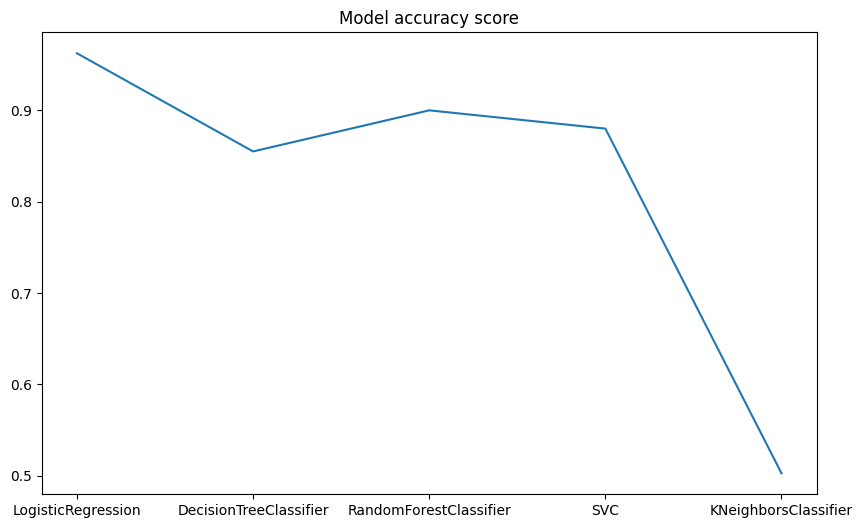

In [52]:
plt.figure(figsize=(10,6))
sns.lineplot(x=models.keys(),y=acc_score)
plt.title("Model accuracy score")
plt.show()

In [57]:
# use test data
X_test_scaler

array([[-0.47545131,  0.968496  ,  0.31260069, ...,  1.        ,
        -1.01409939, -0.69989707],
       [-0.94278218,  0.968496  , -1.25583195, ..., -1.        ,
        -1.01409939, -0.29740112],
       [ 1.29207729,  0.968496  ,  1.51908734, ...,  1.        ,
         0.98609664,  1.07961244],
       ...,
       [-0.1469316 , -1.03252879, -0.16999397, ..., -1.        ,
        -1.01409939, -0.6063618 ],
       [ 0.65817305,  0.968496  , -1.25583195, ...,  1.        ,
        -1.01409939, -1.06127235],
       [ 0.04971753,  0.968496  , -1.25583195, ..., -1.        ,
         0.98609664, -0.75175483]], shape=(1000, 21))

In [68]:
X_test_scaler.shape

(1000, 21)

In [70]:
test_data.drop('id', axis=1, inplace=True)

In [93]:
# import 'logisticRegressin' -- accuracy score: 96 %
# from X_test_scaled_df take sample of 400 records since, y_test has 400 records
lg = joblib.load('LogisticRegression_classifer.pkl')
lg_pred = lg.predict(X_test_scaler)
print("Accuracy Score: ", accuracy_score(y.sample(n=1000),lg_pred))

Accuracy Score:  0.282
